In [53]:
import numpy as np
from sklearn.datasets import load_diabetes

In [54]:
X,y = load_diabetes(return_X_y=True)

In [55]:
class SGDRegressor:
    def __init__(self,lr=0.01,epochs=100): 
        self.lr = lr
        self.epochs = epochs
        self.intercept_ = 0
        self.coef_ = None
        self.history = []
    
    def fit(self,X,y):
        self.coef_ = np.ones(X.shape[1])
        for _ in range(self.epochs): 
            for _ in range(X.shape[0]):
                idx = np.random.randint(0,X.shape[0])
                y_hat = np.dot(X[idx],self.coef_) + self.intercept_
                self.intercept_ = self.intercept_ + 2*self.lr*(y[idx]-y_hat)
                self.coef_ = self.coef_ + 2*self.lr*np.dot(y[idx]-y_hat, X[idx])
                self.history.append((self.intercept_,self.coef_))
        return self.intercept_,self.coef_
    def predict(self,X):
        return np.dot(X,self.coef_)+self.intercept_

In [56]:
sgd = SGDRegressor()
intercept_,coef_=sgd.fit(X,y)
intercept_

np.float64(152.87377268721056)

In [57]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,random_state=40,noise=20)
m = np.linspace(-120,120)
b =np.linspace(-120,120)
mm,bb = np.meshgrid(m,b)


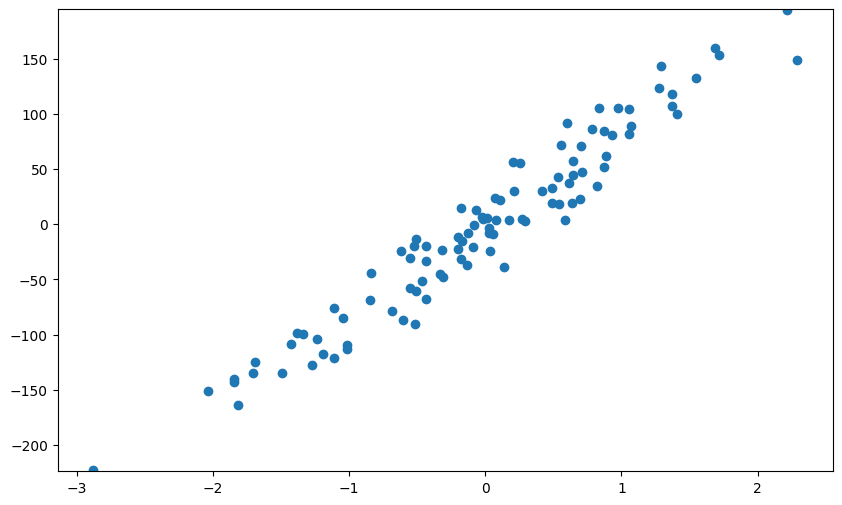

In [58]:
plt.figure(figsize=(10,6))
plt.ylim(y.min()-1,y.max()+1)
plt.scatter(X.ravel(),y)

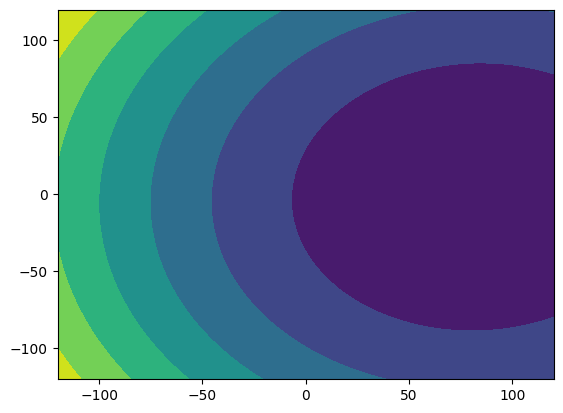

In [59]:
grid = np.column_stack([mm.ravel(),bb.ravel()])
z = np.array([np.mean((y - m*X.ravel() - b)**2)/100 for m,b in grid])
plt.contourf(mm,bb,z.reshape(mm.shape))

In [79]:
sgd1 = SGDRegressor(epochs=1)
intercept_,coef_ = sgd1.fit(X,y)

In [80]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
sgd1.history

[(np.float64(0.6436805419163187), array([1.31761998])),
 (np.float64(0.3347098813886574), array([1.37106008])),
 (np.float64(2.407190545175256), array([3.10437673])),
 (np.float64(4.382526731175566), array([5.18323591])),
 (np.float64(4.088314697662357), array([5.33269415])),
 (np.float64(4.876269917733605), array([5.89235273])),
 (np.float64(2.9796609454127916), array([8.50823151])),
 (np.float64(2.729908053618327), array([8.4947266])),
 (np.float64(2.610460578908478), array([8.49141651])),
 (np.float64(4.518324201759512), array([10.08705591])),
 (np.float64(2.3154659438181597), array([12.7056488])),
 (np.float64(1.4464421870621078), array([12.99390125])),
 (np.float64(2.947526370756049), array([14.17405594])),
 (np.float64(2.6099016814631204), array([14.32092294])),
 (np.float64(0.11504660248021681), array([19.39273768])),
 (np.float64(0.3068226732285952), array([19.48647975])),
 (np.float64(-1.541587044568624), array([22.6152545])),
 (np.float64(0.7670523081496115), array([25.598051

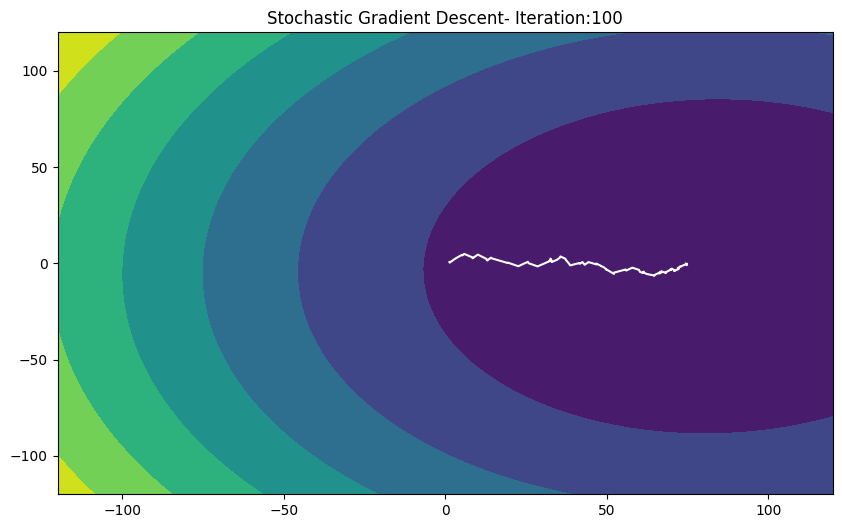

In [84]:
fig,ax = plt.subplots(figsize=(10,6))
ax.contourf(mm,bb,z.reshape(mm.shape))
line,=ax.plot([],[],color='white')
title = ax.set_title("Stochastic Gradient Descent")
plot_data_x=[]
plot_data_y=[]
def update(frame):
    b,m = sgd1.history[frame]
    plot_data_x.append(m[0])
    plot_data_y.append(b)
    line.set_data(plot_data_x,plot_data_y)
    title.set_text(f"Stochastic Gradient Descent- Iteration:{frame+1}")
    return [title]

anim = FuncAnimation(fig,
                     update,
                     frames=len(sgd1.history),
                     interval=100,
                     blit=True)
HTML(anim.to_jshtml())